# TransE from Scratch - Colab Implementation


### Translating Embeddings for Modeling Multi-relational Data (NeurIPS, 2013) 에서 제안한 알고리즘을 파이썬 코드로 구현

**구현 범위**
- Uniform 초기화 ($Unif(-6/\sqrt{k}, 6/\sqrt{k})$)
- 매 epoch마다 entity normalization
- Negative sampling (corrupted triplet, head 또는 tail 중 하나만 교체)
- Margin-based ranking loss
- Link prediction 평가 (raw / filtered, MRR, Hits@10)

**데이터셋**: FB15k-237 (논문 원본의 FB15k 후속, head/tail 역방향 관계 제거된 정제 버전)

## 1. Environment 

In [5]:
!pip install torch --quiet
import torch
print("Cuda available:", torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Cuda available: False
Using device: cpu


## 2. Download Dataset (FB15k-237)

표준 KGE 벤치마크인 FB15k-237 사용, train/validation/test가 각각 `(head, relation, tail)` 탭 구분 텍스트 파일로 구성

In [6]:
import os, urllib.request, urllib.error

DATA_DIR = "fb15k237"
os.makedirs(DATA_DIR, exist_ok=True)

files = ["train.txt", "valid.txt", "test.txt"]

# 여러 미러를 순서대로 시도합니다 (첫 번째가 막히면 다음 미러로 자동 전환).
# 1) DeepGraphLearning/KnowledgeGraphEmbedding (RotatE 공식 repo, 압축 없이 raw txt 제공)
# 2) villmow/datasets_knowledge_embedding (구버전 fallback, 일부 경로가 tar.xz로 바뀌어 실패할 수 있음)
MIRRORS = [
    "https://github.com/DeepGraphLearning/KnowledgeGraphEmbedding/raw/master/data/FB15k-237",
    "https://raw.githubusercontent.com/DeepGraphLearning/KnowledgeGraphEmbedding/master/data/FB15k-237",
]

def download_with_fallback(fname, dest_path):
    last_err = None
    for base_url in MIRRORS:
        url = f"{base_url}/{fname}"
        try:
            print(f"trying: {url}")
            urllib.request.urlretrieve(url, dest_path)
            # 너무 작은 파일(에러 페이지 등)이 받아졌는지 간단히 점검
            if os.path.getsize(dest_path) < 1000:
                raise ValueError("downloaded file is suspiciously small, likely not the real data")
            print(f"  -> success ({os.path.getsize(dest_path)} bytes)")
            return
        except (urllib.error.HTTPError, urllib.error.URLError, ValueError) as e:
            print(f"  -> failed: {e}")
            last_err = e
            if os.path.exists(dest_path):
                os.remove(dest_path)
    raise RuntimeError(f"모든 미러에서 {fname} 다운로드 실패: {last_err}")

for fname in files:
    path = os.path.join(DATA_DIR, fname)
    if not os.path.exists(path):
        download_with_fallback(fname, path)

for fname in files:
    with open(os.path.join(DATA_DIR, fname)) as f:
        n = sum(1 for _ in f)
    print(fname, n, "triples")


trying: https://github.com/DeepGraphLearning/KnowledgeGraphEmbedding/raw/master/data/FB15k-237/train.txt
  -> success (21277292 bytes)
trying: https://github.com/DeepGraphLearning/KnowledgeGraphEmbedding/raw/master/data/FB15k-237/valid.txt
  -> success (1303101 bytes)
trying: https://github.com/DeepGraphLearning/KnowledgeGraphEmbedding/raw/master/data/FB15k-237/test.txt
  -> success (1519499 bytes)
train.txt 272115 triples
valid.txt 17535 triples
test.txt 20466 triples


## 3. Load Data & Build Entity / Relation Dictionary

In [7]:
def load_triples(path):
    triples = []
    with open(path, encoding="utf-8") as f:
        for line in f:
            h, r, t = line.strip().split("\t")
            triples.append((h, r, t))
    return triples

train_raw = load_triples(os.path.join(DATA_DIR, "train.txt"))
valid_raw = load_triples(os.path.join(DATA_DIR, "valid.txt"))
test_raw  = load_triples(os.path.join(DATA_DIR, "test.txt"))

# 엔티티/관계 dictionary (지난 대화에서 다룬 "사전 = 엔티티 집합") 구축
all_triples_raw = train_raw + valid_raw + test_raw
entities = sorted(set(h for h, r, t in all_triples_raw) | set(t for h, r, t in all_triples_raw))
relations = sorted(set(r for h, r, t in all_triples_raw))

ent2id = {e: i for i, e in enumerate(entities)}
rel2id = {r: i for i, r in enumerate(relations)}

n_e, n_r = len(entities), len(relations)
print(f"n_e (entities) = {n_e}, n_r (relations) = {n_r}")

def to_id_triples(raw):
    return torch.tensor(
        [[ent2id[h], rel2id[r], ent2id[t]] for h, r, t in raw],
        dtype=torch.long,
    )

train = to_id_triples(train_raw)
valid = to_id_triples(valid_raw)
test  = to_id_triples(test_raw)

print("train/valid/test:", train.shape, valid.shape, test.shape)

# filtered 평가용: 실제로 참인 모든 triple을 (h, r) -> {t...}, (r, t) -> {h...} 로 모아둠
all_triples = torch.cat([train, valid, test], dim=0)


n_e (entities) = 14541, n_r (relations) = 237
train/valid/test: torch.Size([272115, 3]) torch.Size([17535, 3]) torch.Size([20466, 3])


## 4. TransE 모델 구현
알고리즘 그대로:

1. **Initialization**: $Unif(-\frac{6}{\sqrt{k}}, \frac{6}{\sqrt{k}})$ 로 entity/relation 초기화, relation은 초기화 직후 normalize
2. **Loop**: 매 epoch마다 entity normalize → 미니배치 샘플링 → negative sampling → margin loss로 업데이트


In [8]:
import torch.nn as nn
import torch.nn.functional as F

class TransE(nn.Module):
    def __init__(self, n_entities, n_relations, k=50, margin=1.0, p_norm=1):
        super().__init__()
        self.k = k
        self.margin = margin
        self.p_norm = p_norm  # L1 또는 L2 거리 (논문에서 d = L1 or L2)

        bound = 6 / (k ** 0.5)  # Unif(-6/sqrt(k), 6/sqrt(k))
        self.entity_emb = nn.Parameter(torch.empty(n_entities, k).uniform_(-bound, bound))
        self.relation_emb = nn.Parameter(torch.empty(n_relations, k).uniform_(-bound, bound))

        # relation은 초기화 시 한 번 normalize (알고리즘 1단계)
        with torch.no_grad():
            self.relation_emb.data = F.normalize(self.relation_emb.data, p=2, dim=1)

    def normalize_entities(self):
        # 매 loop마다 entity normalize (알고리즘 loop 1단계) — 스케일 폭주/붕괴 방지
        with torch.no_grad():
            self.entity_emb.data = F.normalize(self.entity_emb.data, p=2, dim=1)

    def distance(self, h, r, t):
        # d(h + l, t) = ||h + l - t||_p
        h_emb = self.entity_emb[h]
        r_emb = self.relation_emb[r]
        t_emb = self.entity_emb[t]
        return torch.norm(h_emb + r_emb - t_emb, p=self.p_norm, dim=-1)

    def forward(self, pos_triples, neg_triples):
        # margin-based ranking loss: [gamma + d(pos) - d(neg)]_+
        h, r, t = pos_triples[:, 0], pos_triples[:, 1], pos_triples[:, 2]
        h_n, r_n, t_n = neg_triples[:, 0], neg_triples[:, 1], neg_triples[:, 2]

        d_pos = self.distance(h, r, t)
        d_neg = self.distance(h_n, r_n, t_n)

        loss = F.relu(self.margin + d_pos - d_neg)
        return loss.mean()


## 5. Negative Sampling (Corrupted Triplet)
head 또는 tail 중 하나만 무작위 엔티티로 교체

In [9]:
def corrupt_batch(batch, n_entities):
    """batch: (B, 3) tensor of (h, r, t). head 또는 tail 중 하나를 무작위로 교체."""
    neg = batch.clone()
    B = batch.size(0)
    corrupt_head = torch.rand(B) < 0.5  # 동전 던지기로 head/tail 중 어디를 깰지 결정

    rand_entities = torch.randint(0, n_entities, (B,))
    neg[corrupt_head, 0] = rand_entities[corrupt_head]
    neg[~corrupt_head, 2] = rand_entities[~corrupt_head]
    return neg

## 6. Training

In [10]:
from torch.utils.data import DataLoader, TensorDataset
import time

# 하이퍼파라미터 (논문 FB15k 세팅과 유사하게: k=50, margin=1, L1 distance)
K = 50
MARGIN = 1.0
P_NORM = 1
LR = 0.01
BATCH_SIZE = 1024
EPOCHS = 100  # Colab 무료 GPU 기준 적당한 epoch 수. 시간 여유 있으면 늘려도 됩니다.

model = TransE(n_e, n_r, k=K, margin=MARGIN, p_norm=P_NORM).to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=LR)

train_ds = TensorDataset(train)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

history = []
start = time.time()

for epoch in range(1, EPOCHS + 1):
    model.normalize_entities()  # loop 1단계: 매 epoch마다 entity 정규화
    total_loss = 0.0

    for (batch,) in train_loader:
        batch = batch.to(device)
        neg_batch = corrupt_batch(batch, n_e).to(device)

        optimizer.zero_grad()
        loss = model(batch, neg_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * batch.size(0)

    avg_loss = total_loss / len(train_ds)
    history.append(avg_loss)

    if epoch % 10 == 0 or epoch == 1:
        elapsed = time.time() - start
        print(f"Epoch {epoch:3d} | loss {avg_loss:.4f} | elapsed {elapsed:.1f}s")


Epoch   1 | loss 1.0961 | elapsed 3.5s
Epoch  10 | loss 1.0298 | elapsed 38.1s
Epoch  20 | loss 0.9876 | elapsed 77.0s
Epoch  30 | loss 0.9543 | elapsed 113.6s
Epoch  40 | loss 0.9329 | elapsed 150.7s
Epoch  50 | loss 0.9081 | elapsed 186.6s
Epoch  60 | loss 0.8878 | elapsed 223.7s
Epoch  70 | loss 0.8694 | elapsed 260.0s
Epoch  80 | loss 0.8555 | elapsed 296.0s
Epoch  90 | loss 0.8370 | elapsed 332.3s
Epoch 100 | loss 0.8253 | elapsed 368.8s


## 7. Training Curve Visualization

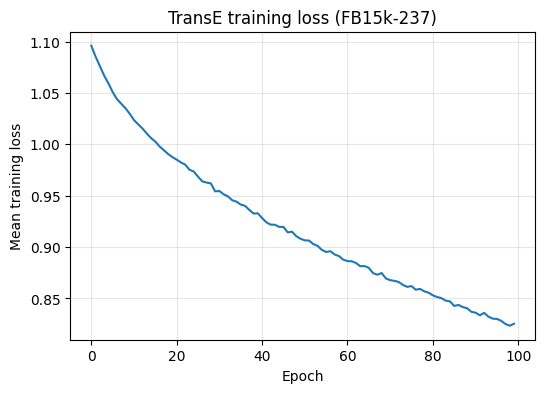

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(history)
plt.xlabel("Epoch")
plt.ylabel("Mean training loss")
plt.title("TransE training loss (FB15k-237)")
plt.grid(alpha=0.3)
plt.show()


## 8. Evaluation: Link Prediction (Raw / Filtered, MRR, Hits@10)
1. 각 테스트 triple마다 head를 전체 엔티티로, tail을 전체 엔티티로 각각 교체
2. 거리 계산 → 오름차순 정렬 → 정답의 순위(rank) 기록
3. **filtered**: 정답을 제외한, train/valid/test에 실제로 존재하는 다른 참인 triple들을 후보에서 제거

In [12]:
@torch.no_grad()
def build_filter_sets(all_triples):
    """filtered 평가를 위해, (r, t) -> 참인 head 집합 / (h, r) -> 참인 tail 집합을 구축"""
    tails_given_hr = {}
    heads_given_rt = {}
    for h, r, t in all_triples.tolist():
        tails_given_hr.setdefault((h, r), set()).add(t)
        heads_given_rt.setdefault((r, t), set()).add(h)
    return tails_given_hr, heads_given_rt

tails_given_hr, heads_given_rt = build_filter_sets(all_triples)

@torch.no_grad()
def evaluate(model, test_triples, n_entities, device, batch_size=64, hits_k=10, max_samples=None):
    model.eval()
    all_entities = torch.arange(n_entities, device=device)

    ranks_raw, ranks_filt = [], []

    triples = test_triples if max_samples is None else test_triples[:max_samples]

    for idx in range(0, len(triples), batch_size):
        chunk = triples[idx: idx + batch_size]

        for h, r, t in chunk.tolist():
            h_t = torch.tensor(h, device=device)
            r_t = torch.tensor(r, device=device)
            t_t = torch.tensor(t, device=device)

            # ---- tail 예측: (h, r, ?) ----
            h_rep = h_t.repeat(n_entities)
            r_rep = r_t.repeat(n_entities)
            d_tail = model.distance(h_rep, r_rep, all_entities)
            rank_raw = (d_tail < d_tail[t]).sum().item() + 1

            filt_mask = torch.zeros(n_entities, dtype=torch.bool, device=device)
            true_tails = tails_given_hr.get((h, r), set()) - {t}
            if true_tails:
                filt_mask[list(true_tails)] = True
            d_tail_filt = d_tail.clone()
            d_tail_filt[filt_mask] = float("inf")
            rank_filt = (d_tail_filt < d_tail_filt[t]).sum().item() + 1

            ranks_raw.append(rank_raw)
            ranks_filt.append(rank_filt)

            # ---- head 예측: (?, r, t) ----
            t_rep = t_t.repeat(n_entities)
            r_rep2 = r_t.repeat(n_entities)
            d_head = model.distance(all_entities, r_rep2, t_rep)
            rank_raw_h = (d_head < d_head[h]).sum().item() + 1

            filt_mask_h = torch.zeros(n_entities, dtype=torch.bool, device=device)
            true_heads = heads_given_rt.get((r, t), set()) - {h}
            if true_heads:
                filt_mask_h[list(true_heads)] = True
            d_head_filt = d_head.clone()
            d_head_filt[filt_mask_h] = float("inf")
            rank_filt_h = (d_head_filt < d_head_filt[h]).sum().item() + 1

            ranks_raw.append(rank_raw_h)
            ranks_filt.append(rank_filt_h)

    ranks_raw = torch.tensor(ranks_raw, dtype=torch.float)
    ranks_filt = torch.tensor(ranks_filt, dtype=torch.float)

    def summarize(ranks):
        mr = ranks.mean().item()
        mrr = (1.0 / ranks).mean().item()
        hits = (ranks <= hits_k).float().mean().item()
        return mr, mrr, hits

    mr_raw, mrr_raw, hits_raw = summarize(ranks_raw)
    mr_filt, mrr_filt, hits_filt = summarize(ranks_filt)

    print(f"[RAW]      Mean Rank: {mr_raw:.1f} | MRR: {mrr_raw:.4f} | Hits@{hits_k}: {hits_raw:.4f}")
    print(f"[FILTERED] Mean Rank: {mr_filt:.1f} | MRR: {mrr_filt:.4f} | Hits@{hits_k}: {hits_filt:.4f}")

    return {
        "raw": {"mean_rank": mr_raw, "mrr": mrr_raw, "hits@10": hits_raw},
        "filtered": {"mean_rank": mr_filt, "mrr": mrr_filt, "hits@10": hits_filt},
    }

# 전체 test set 평가는 시간이 걸릴 수 있어, 먼저 일부 샘플(예: 500개)로 빠르게 확인 후 전체로 확장하세요.
results = evaluate(model, test.to(device), n_e, device, max_samples=500)


[RAW]      Mean Rank: 5285.8 | MRR: 0.0314 | Hits@10: 0.0610
[FILTERED] Mean Rank: 5162.1 | MRR: 0.0318 | Hits@10: 0.0610


## 9. (Optional) Overall Test set evaluation
위에서 샘플로 잘 동작하는 걸 확인했다면, `max_samples=None`으로 전체 test set을 평가 (GPU 권장)

In [13]:
# results_full = evaluate(model, test.to(device), n_e, device, max_samples=None)


## 10. Save Model

In [14]:
torch.save({
    "entity_emb": model.entity_emb.detach().cpu(),
    "relation_emb": model.relation_emb.detach().cpu(),
    "ent2id": ent2id,
    "rel2id": rel2id,
    "config": {"k": K, "margin": MARGIN, "p_norm": P_NORM},
}, "transE_fb15k237.pt")

print("saved to transE_fb15k237.pt")


saved to transE_fb15k237.pt
